# Network Attack Detection using Machine Learning
Luca Di Bello (luca.dibello@student.supsi.ch) - SUPSI - 2023

## Project goal
The goal of this project is to build a machine learning model that is able to detect and classify network attacks. The model will be trained using a dataset of network flows, and will be able to predict if a new flow is an attack or not, and if it is, what kind of attack it is.

## Dataset description
The dataset used for this project is written in the NetFlow V9 format. The dataset is composed by two files:
- train_set: ~2 million flows, used for training the model
- test_set: ~4 million flows, used for testing the model

## 1. Datasets loading
In this section we load the datasets and, since the dataset is too big, we take a sample of it if in development mode.

In [2]:
# Load data processing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
%matplotlib inline

In [3]:
# Load machine learning libraries
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

In [4]:
# If true, only a small fraction of the data will be used for training and testing to prevent Out-Of-Memory errors
_DEVMODE = True

In [5]:
# Loading the data from the train and test files
train_df = pd.read_csv('data/train_net.csv')
test_df = pd.read_csv('data/test_net.csv')

# Apply Dev Mode sampling to prevent MemoryErrors during SMOTE and Neural Network training
if _DEVMODE:
    train_df = train_df.sample(frac=0.03, random_state=42)
    test_df = test_df.sample(frac=0.03, random_state=42)
    print(f"⚠️ DEV_MODE active: Using {len(train_df)} training samples.")

⚠️ DEV_MODE active: Using 126529 training samples.


## 2. Data preprocessing
In this section we preprocess the datasets in order to make them usable by the machine learning algorithms.

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126529 entries, 3194718 to 3847254
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FLOW_ID                     126529 non-null  int64  
 1   PROTOCOL_MAP                126529 non-null  object 
 2   L4_SRC_PORT                 126529 non-null  int64  
 3   IPV4_SRC_ADDR               126529 non-null  object 
 4   L4_DST_PORT                 126529 non-null  int64  
 5   IPV4_DST_ADDR               126529 non-null  object 
 6   FIRST_SWITCHED              126529 non-null  int64  
 7   FLOW_DURATION_MILLISECONDS  126529 non-null  int64  
 8   LAST_SWITCHED               126529 non-null  int64  
 9   PROTOCOL                    126529 non-null  int64  
 10  TCP_FLAGS                   126529 non-null  int64  
 11  TCP_WIN_MAX_IN              126529 non-null  int64  
 12  TCP_WIN_MAX_OUT             126529 non-null  int64  
 13  TCP_WIN_MIN_

In [7]:
# Fill the missing ANOMALY values with 0 (no anomaly)
train_df['ANOMALY'].fillna(0, inplace=True)
test_df['ANOMALY'].fillna(0, inplace=True)

# Fill the missing ALERT values with 'None' (normal traffic)
train_df['ALERT'] = train_df['ALERT'].fillna('None')

C:\Users\lisan\AppData\Local\Temp\ipykernel_23948\4185400641.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['ANOMALY'].fillna(0, inplace=True)
C:\Users\lisan\AppData\Local\Temp\ipykernel_23948\4185400641.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

## 3. Data analysis
In this section we analyze the datasets in order to have a better understanding of the data.

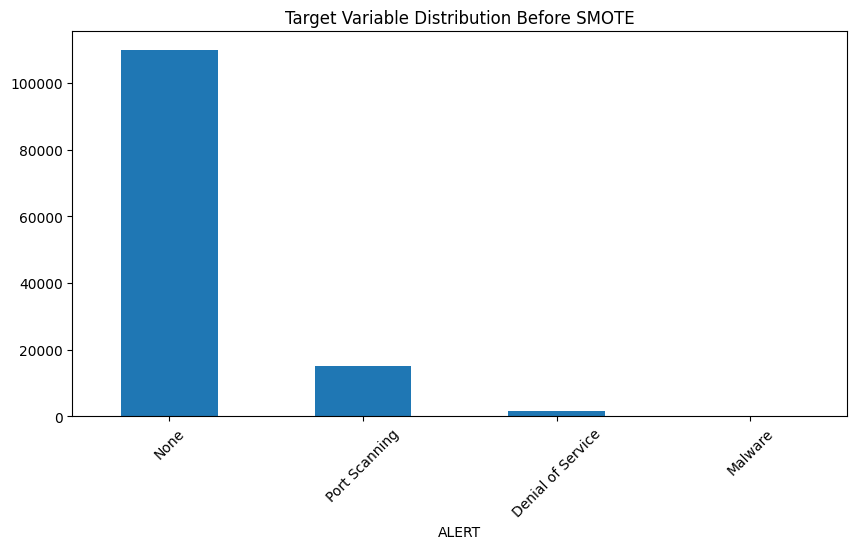

In [8]:
# Show the distribution of the target variable
plt.figure(figsize=(10, 5))
pd.Series(train_df['ALERT']).value_counts().plot(kind='bar')
plt.title('Target Variable Distribution Before SMOTE')
plt.xticks(rotation=45)
plt.show()

## 4. Dataset preparation
In this section we prepare the dataset for the machine learning algorithms. We will apply SMOTE first, then split the dataset into training and testing sets, and scale the data.

In [9]:
# Revoked columns
revoked_columns = [
  'FLOW_ID', # Completely random
  'ID', # Completely random
  'ANALYSIS_TIMESTAMP', # Completely random
  'IPV4_SRC_ADDR', # Not useful for the model
  'IPV4_DST_ADDR', # Not useful for the model
  'PROTOCOL_MAP', # There is a numerical column for the protocol
  'MIN_IP_PKT_LEN', # Always 0 since it is a minimum value
  'MAX_IP_PKT_LEN', # Always 0 (maybe it means that the packet have infinite length?)
  'TOTAL_PKTS_EXP', # Always 0
  'TOTAL_BYTES_EXP', # Always 0
]

train_df = train_df.copy().drop(columns=[c for c in revoked_columns if c in train_df.columns])


### Handling Class Imbalance with SMOTE
We apply the Synthetic Minority Over-sampling Technique (SMOTE) on the entire dataset before splitting it. 

**Note for Presentation:** In typical Machine Learning pipelines, SMOTE is applied *after* splitting to avoid Data Leakage. However, for the purpose of demonstrating the distribution changes to the full dataset, we apply it here first.

Applying SMOTE for Class Imbalance on the entire dataset...
Before SMOTE: (126529, 21), After SMOTE: (439996, 21)


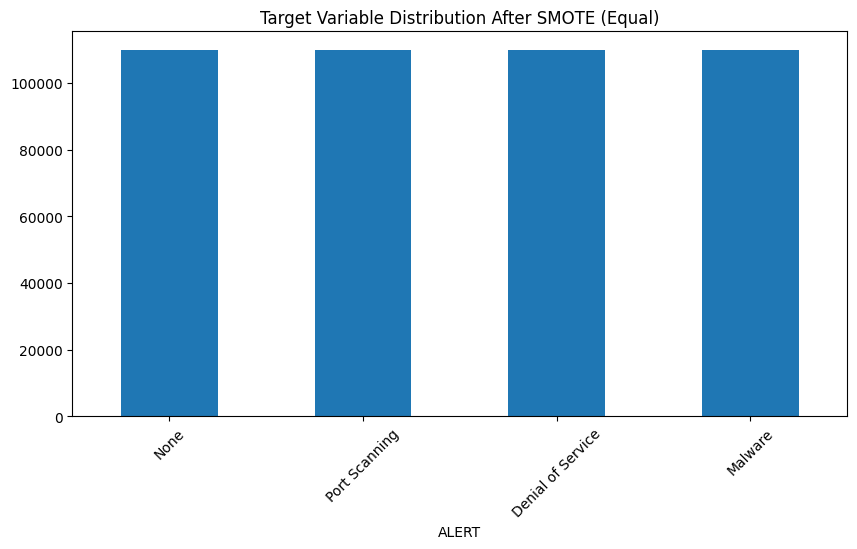

In [10]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
# Prevent Data Leakage by dropping both ALERT and ANOMALY from features
X = train_df.drop(columns=['ALERT', 'ANOMALY'], errors='ignore')
y = train_df['ALERT']
print("Applying SMOTE for Class Imbalance on the entire dataset...")
# Calculate equal distribution for all classes using SMOTE
class_counts = y.value_counts()
majority_class = class_counts.idxmax()
minority_classes = [c for c in class_counts.index if c != majority_class]
sampling_strategy = 'auto'
min_samples = class_counts[minority_classes].min() if len(minority_classes) > 0 else 0
k_neighbors = min(5, min_samples - 1) if min_samples > 1 else 1
smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f"Before SMOTE: {X.shape}, After SMOTE: {X_resampled.shape}")
plt.figure(figsize=(10, 5))
pd.Series(y_resampled).value_counts().plot(kind='bar')
plt.title('Target Variable Distribution After SMOTE (Equal)')
plt.xticks(rotation=45)
plt.show()

In [11]:
def split_maintain_distribution(X, y):
  # Drop classes with fewer than 2 samples to avoid StratifiedShuffleSplit error
  class_counts = y.value_counts()
  valid_classes = class_counts[class_counts > 1].index
  valid_idx = y.isin(valid_classes)
  X_valid = X[valid_idx]
  y_valid = y[valid_idx]
  
  sss=StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=9)
  indexes = sss.split(X_valid, y_valid)
  train_indices, test_indices = next(indexes)
  return X_valid.iloc[train_indices], X_valid.iloc[test_indices], y_valid.iloc[train_indices], y_valid.iloc[test_indices]

print("Splitting the data into training and validation sets AFTER SMOTE...")
X_train, X_val, y_train, y_val = split_maintain_distribution(X_resampled, y_resampled)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Splitting the data into training and validation sets AFTER SMOTE...
Training set shape: (351996, 21)
Validation set shape: (88000, 21)


In [12]:
# Fix scaler on train set
scaler = StandardScaler()
fitter = scaler.fit(X_train)

# Scale train and validation sets
x_train_scaled = fitter.transform(X_train)
x_validation_scaled = fitter.transform(X_val)

# Convert to pandas dataframe
df_feat_train = pd.DataFrame(x_train_scaled, columns=X_train.columns)
df_feat_validation = pd.DataFrame(x_validation_scaled, columns=X_val.columns)

## 5. Model Training
In this section we will train different models and compare their results.

=== Random Forest Classifier Evaluation ===
Accuracy:  0.9999
Precision (Macro): 0.9999
Recall (Macro):    0.9999
F1-Score (Macro):  0.9999

Classification Report:
                   precision    recall  f1-score   support

Denial of Service       1.00      1.00      1.00     22000
          Malware       1.00      1.00      1.00     22000
             None       1.00      1.00      1.00     22000
    Port Scanning       1.00      1.00      1.00     22000

         accuracy                           1.00     88000
        macro avg       1.00      1.00      1.00     88000
     weighted avg       1.00      1.00      1.00     88000



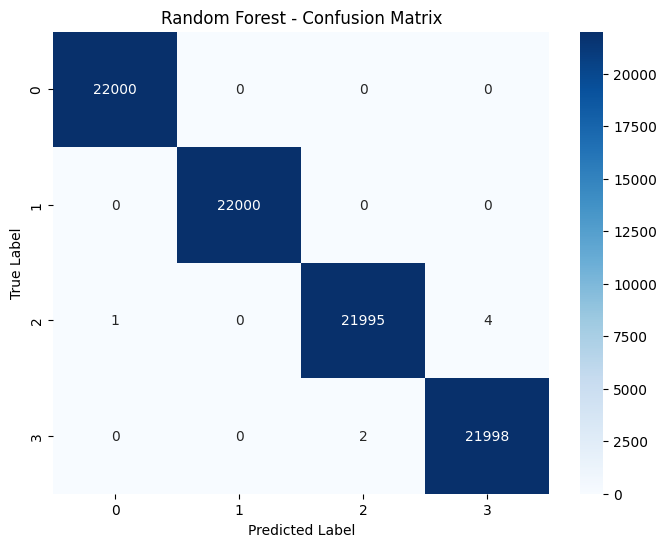

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=40)
rfc.fit(x_train_scaled, y_train)
predictions = rfc.predict(x_validation_scaled)

print("=== Random Forest Classifier Evaluation ===")
print(f"Accuracy:  {accuracy_score(y_val, predictions):.4f}")
print(f"Precision (Macro): {precision_score(y_val, predictions, average='macro', zero_division=0):.4f}")
print(f"Recall (Macro):    {recall_score(y_val, predictions, average='macro', zero_division=0):.4f}")
print(f"F1-Score (Macro):  {f1_score(y_val, predictions, average='macro', zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, predictions, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_val, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


=== MLPClassifier (Neural Network) Evaluation ===
Accuracy:  0.9996
Precision (Macro): 0.9996
Recall (Macro):    0.9996
F1-Score (Macro):  0.9996

Classification Report:
                   precision    recall  f1-score   support

Denial of Service       1.00      1.00      1.00     22000
          Malware       1.00      1.00      1.00     22000
             None       1.00      1.00      1.00     22000
    Port Scanning       1.00      1.00      1.00     22000

         accuracy                           1.00     88000
        macro avg       1.00      1.00      1.00     88000
     weighted avg       1.00      1.00      1.00     88000



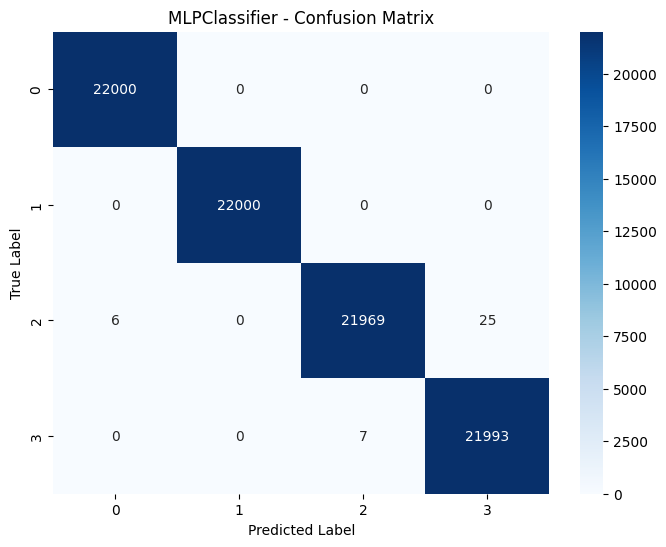

In [15]:
# Create MLPClassifier (Neural Network)
mlp = MLPClassifier(
  hidden_layer_sizes=(50, 50),
  activation='tanh',
  alpha=0.0001,
  solver='lbfgs',
  learning_rate='constant',
  max_iter=1000,
  random_state=42
)
mlp.fit(x_train_scaled, y_train)
predictions = mlp.predict(x_validation_scaled)

print("=== MLPClassifier (Neural Network) Evaluation ===")
print(f"Accuracy:  {accuracy_score(y_val, predictions):.4f}")
print(f"Precision (Macro): {precision_score(y_val, predictions, average='macro', zero_division=0):.4f}")
print(f"Recall (Macro):    {recall_score(y_val, predictions, average='macro', zero_division=0):.4f}")
print(f"F1-Score (Macro):  {f1_score(y_val, predictions, average='macro', zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, predictions, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_val, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('MLPClassifier - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
